# Rede

In [1]:
from src.objetos import Dados, camada_densa, rede_neural

In [2]:
# Caminho dos dados e dos rotulos
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)


In [3]:
# Escolha do método de separação dos dados
dados._holdout(0.6, 0.2)

In [4]:
# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = None
arquitetura_camadas = [400, 25, 10]

In [5]:
# Inicialização das nossas camadas com base na arquitetura dadas
camadas = []

for i in range(len(arquitetura_camadas)-1):
    camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[i], 
        tamanho_saida=arquitetura_camadas[i+1],
        funcao_de_ativacao='entropia_cruzada'
        )
    camadas.append(camada)

# Inicialização da rede neural
rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

In [6]:
# Treinamento da rede neural
rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_reg
)

## Verificação do Modelo

### Cálculo da acurácia com base no conjunto de teste

In [7]:
import numpy as np
y_teste = rede._avalia(dados.conjunto_teste[0])
classes_pred = np.argmax(y_teste, axis=0) + 1
classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
acertos = np.sum(classes_pred == classes_real)
num_amostras = dados.conjunto_teste[0].shape[1]

print("Acurácia do modelo em um conjunto de teste")
print(acertos/num_amostras)


Acurácia do modelo em um conjunto de teste
0.915


## Gráficos

### Leitura dos Logs

In [8]:
import pandas as pd

logs = pd.read_csv("logs.csv")

### Gráfico do custo do conjunto de treinamento e validação em função da epoca

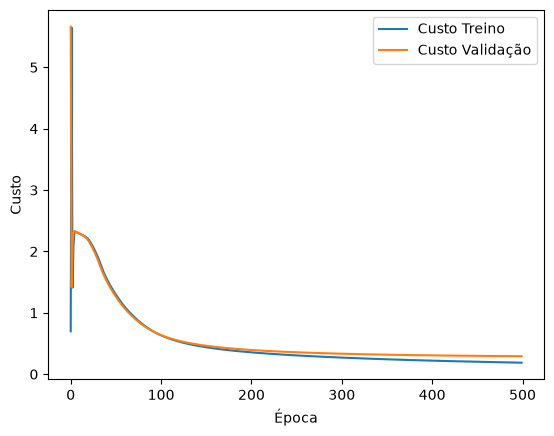

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(logs["epoca"],logs["custo_treino"], label="Custo Treino")
plt.plot(logs["epoca"],logs["custo_validacao"], label="Custo Validação")
plt.xlabel("Época")
plt.ylabel("Custo")
plt.legend()
plt.show()